In [2]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

from xgboost import XGBClassifier

loan_data = pd.read_csv("../data/loan_prediction.csv")

loan_data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
# Dataset shape
print("Dataset Shape:", loan_data.shape)

# Column info
loan_data.info()

# Statistical summary
loan_data.describe()

Dataset Shape: (614, 13)
<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [4]:
print("Missing Values in Each Column:")
print(loan_data.isnull().sum())

Missing Values in Each Column:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


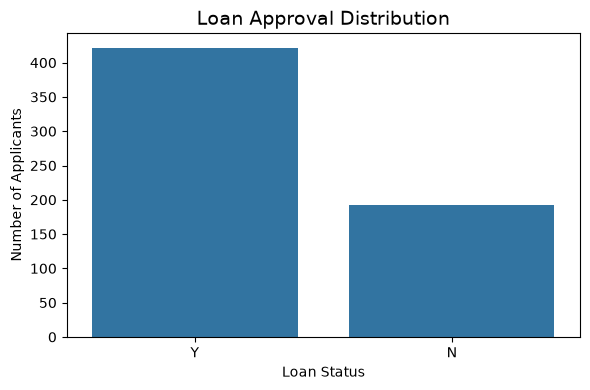

In [5]:
# Loan status distribution
# ============================================================
# Visualization 1: Loan Approval Distribution
# ============================================================
# This graph shows the number of approved (Y) and rejected (N)
# loan applications in the dataset.

plt.figure(figsize=(6, 4))

sns.countplot(x='Loan_Status', data= loan_data)

plt.title("Loan Approval Distribution", fontsize=14)
plt.xlabel("Loan Status")
plt.ylabel("Number of Applicants")

plt.tight_layout()
plt.show()

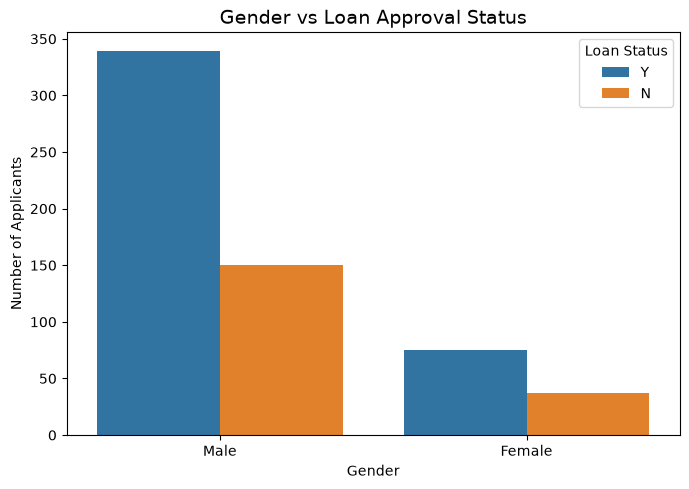

In [6]:
# ============================================================
# Visualization 2: Gender vs Loan Approval
# ============================================================
# This visualization compares loan approval status
# for male and female applicants.

plt.figure(figsize=(7, 5))

sns.countplot(
    x='Gender',
    hue='Loan_Status',
    data= loan_data
)

plt.title("Gender vs Loan Approval Status", fontsize=14)
plt.xlabel("Gender")
plt.ylabel("Number of Applicants")
plt.legend(title="Loan Status")

plt.tight_layout()
plt.show()


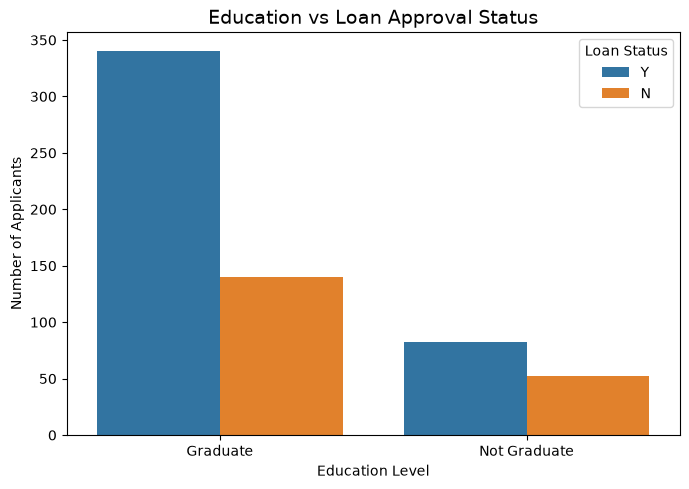

In [7]:
# ============================================================
# Visualization 3: Education vs Loan Approval
# ============================================================
# This graph shows how education level influences
# loan approval decisions.

plt.figure(figsize=(7, 5))

sns.countplot(
    x='Education',
    hue='Loan_Status',
    data= loan_data
)

plt.title("Education vs Loan Approval Status", fontsize=14)
plt.xlabel("Education Level")
plt.ylabel("Number of Applicants")
plt.legend(title="Loan Status")

plt.tight_layout()
plt.show()

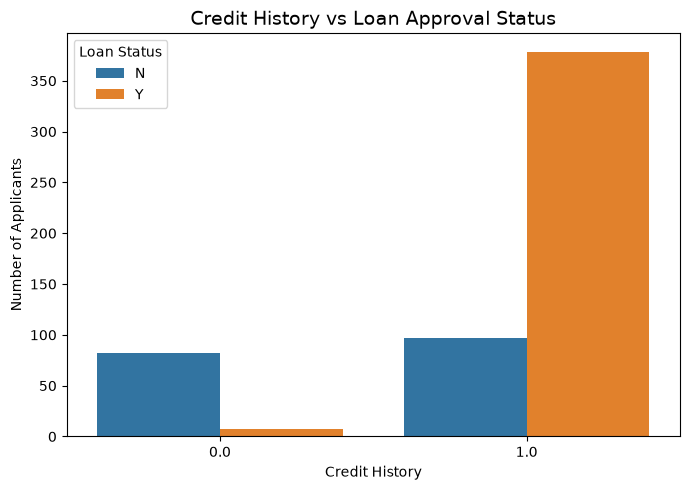

In [8]:
# ============================================================
# Visualization 4: Credit History vs Loan Approval
# ============================================================
# Credit history is one of the most important factors
# affecting loan approval.

plt.figure(figsize=(7, 5))

sns.countplot(
    x='Credit_History',
    hue='Loan_Status',
    data= loan_data
)

plt.title("Credit History vs Loan Approval Status", fontsize=14)
plt.xlabel("Credit History")
plt.ylabel("Number of Applicants")
plt.legend(title="Loan Status")

plt.tight_layout()
plt.show()

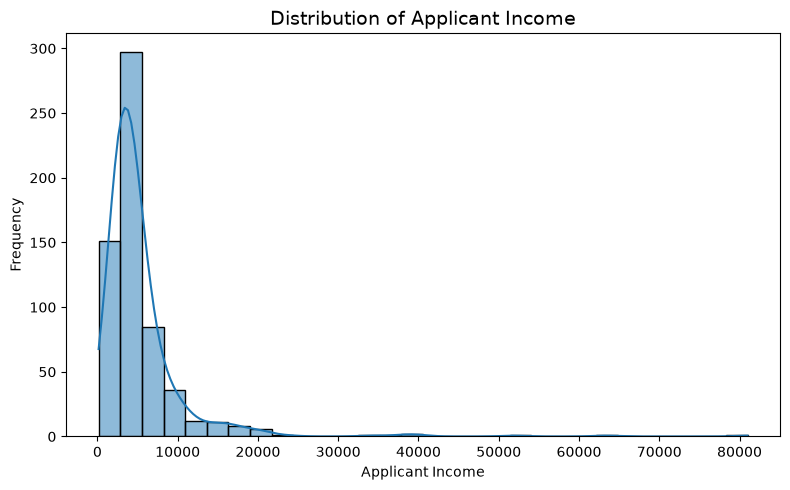

In [9]:
# ============================================================
# Visualization 5: Applicant Income Distribution
# ============================================================
# This histogram shows how applicant income
# is distributed across the dataset.

plt.figure(figsize=(8, 5))

sns.histplot(
    loan_data['ApplicantIncome'],
    bins=30,
    kde=True
)

plt.title("Distribution of Applicant Income", fontsize=14)
plt.xlabel("Applicant Income")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

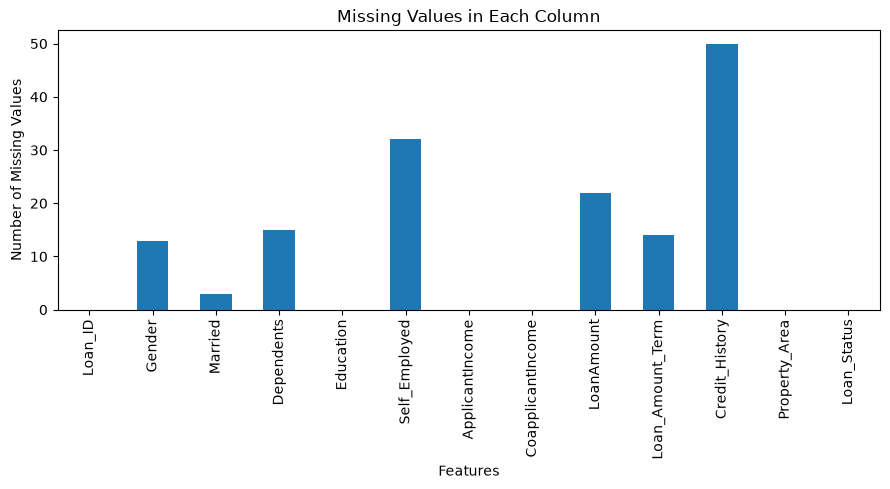

In [10]:
# ============================================================
# Visualization 7: Missing Values in the Dataset
# ============================================================
# This bar chart displays the number of missing values
# present in each feature.

plt.figure(figsize=(9,5))

missing_values = loan_data.isnull().sum()

missing_values.plot(kind='bar')

plt.title("Missing Values in Each Column")
plt.xlabel("Features")
plt.ylabel("Number of Missing Values")

plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# Data Preprocessing
# ============================================================
# Handle missing values before training the machine learning models.
# Categorical features are filled using the mode (most frequent value),
# while numerical features are filled using the median to reduce
# the effect of outliers.

# Fill missing values in categorical columns
loan_data['Gender'] = loan_data['Gender'].fillna(loan_data['Gender'].mode()[0])
loan_data['Married'] = loan_data['Married'].fillna(loan_data['Married'].mode()[0])
loan_data['Dependents'] = loan_data['Dependents'].fillna(loan_data['Dependents'].mode()[0])
loan_data['Self_Employed'] = loan_data['Self_Employed'].fillna(loan_data['Self_Employed'].mode()[0])

# Fill missing values in numerical columns
loan_data['LoanAmount'] = loan_data['LoanAmount'].fillna(loan_data['LoanAmount'].median())
loan_data['Loan_Amount_Term'] = loan_data['Loan_Amount_Term'].fillna(loan_data['Loan_Amount_Term'].median())
loan_data['Credit_History'] = loan_data['Credit_History'].fillna(loan_data['Credit_History'].median())

# Verify that all missing values have been handled
print("Missing values after preprocessing:")
print(loan_data.isnull().sum())

Missing values after preprocessing:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [12]:
# ============================================================
# Feature Engineering
# ============================================================
# Convert the target variable (Loan_Status) into numerical values.
# Approved (Y) -> 1
# Rejected (N) -> 0

loan_data['Loan_Status'] = loan_data['Loan_Status'].map({
    'N': 0,
    'Y': 1
})

# Separate input features and target variable
X = loan_data.drop(columns=['Loan_Status', 'Loan_ID'])
y = loan_data['Loan_Status']
# ============================================================
# Encode Categorical Variables
# ============================================================
# Convert categorical features into numerical values
# using One-Hot Encoding.

X = pd.get_dummies(X)

# Display the encoded dataset
X.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Female,Gender_Male,Married_No,Married_Yes,Dependents_0,Dependents_1,Dependents_2,Dependents_3+,Education_Graduate,Education_Not Graduate,Self_Employed_No,Self_Employed_Yes,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,5849,0.0,128.0,360.0,1.0,False,True,True,False,True,False,False,False,True,False,True,False,False,False,True
1,4583,1508.0,128.0,360.0,1.0,False,True,False,True,False,True,False,False,True,False,True,False,True,False,False
2,3000,0.0,66.0,360.0,1.0,False,True,False,True,True,False,False,False,True,False,False,True,False,False,True
3,2583,2358.0,120.0,360.0,1.0,False,True,False,True,True,False,False,False,False,True,True,False,False,False,True
4,6000,0.0,141.0,360.0,1.0,False,True,True,False,True,False,False,False,True,False,True,False,False,False,True


In [13]:
# ============================================================
# Split Dataset
# ============================================================
# Split the dataset into training and testing sets.
# 80% of the data is used for training,
# while 20% is reserved for testing.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
# ============================================================
# Feature Scaling
# ============================================================
# Scale numerical features for algorithms that rely on
# distance calculations such as K-Nearest Neighbors (KNN).

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# ============================================================
# Decision Tree Classifier
# ============================================================

decision_tree_model = DecisionTreeClassifier(random_state=42)

decision_tree_model.fit(X_train, y_train)

decision_tree_predictions = decision_tree_model.predict(X_test)

decision_tree_accuracy = accuracy_score(
    y_test,
    decision_tree_predictions
)
print("Decision Tree Accuracy:", decision_tree_accuracy)


Decision Tree Accuracy: 0.7154471544715447


In [14]:
# ============================================================
# K-Nearest Neighbors (KNN)
# ============================================================

knn_model = KNeighborsClassifier()

knn_model.fit(
    X_train_scaled,
    y_train
)

knn_predictions = knn_model.predict(
    X_test_scaled
)

knn_accuracy = accuracy_score(
    y_test,
    knn_predictions
)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.7560975609756098


In [15]:
# ============================================================
# XGBoost Classifier
# ============================================================

xgboost_model = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

xgboost_model.fit(X_train, y_train)

xgboost_predictions = xgboost_model.predict(X_test)

xgboost_accuracy = accuracy_score(
    y_test,
    xgboost_predictions
)

print("XGBoost Accuracy:", xgboost_accuracy)

XGBoost Accuracy: 0.7642276422764228


In [16]:
# ============================================================
# Random Forest Classifier
# ============================================================

random_forest_model = RandomForestClassifier(
    random_state=42,
    n_estimators=200
)

random_forest_model.fit(X_train, y_train)

random_forest_predictions = random_forest_model.predict(X_test)

random_forest_accuracy = accuracy_score(
    y_test,
    random_forest_predictions
)

print("Random Forest Accuracy:", random_forest_accuracy)

Random Forest Accuracy: 0.7560975609756098


In [17]:
# ============================================================
# Model Performance Comparison
# ============================================================
# Compare the accuracy of all trained models.

model_results = pd.DataFrame({
    "Machine Learning Model": [
        "Decision Tree",
        "K-Nearest Neighbors",
        "XGBoost",
        "Random Forest"
    ],
    "Accuracy": [
        decision_tree_accuracy,
        knn_accuracy,
        xgboost_accuracy,
        random_forest_accuracy
    ]
})

model_results = model_results.sort_values(
    by="Accuracy",
    ascending=False
)

model_results

,Machine Learning Model,Accuracy
2,XGBoost,0.764228
1,K-Nearest Neighbors,0.756098
3,Random Forest,0.756098
0,Decision Tree,0.715447


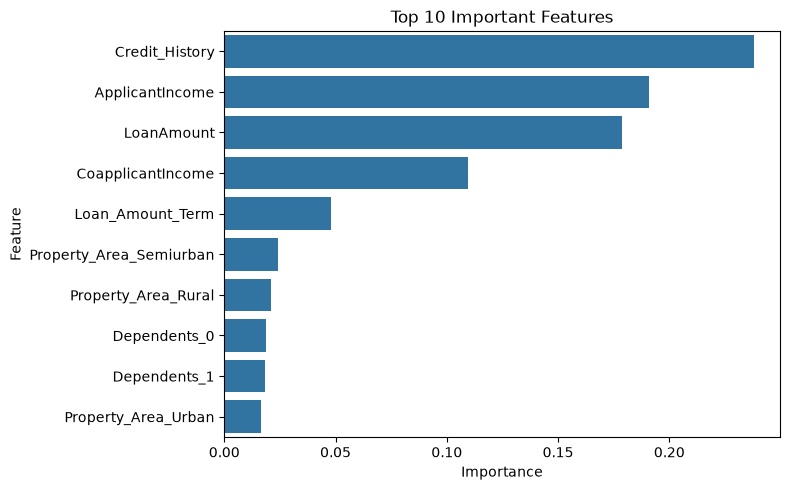

In [18]:
# ============================================================
# Feature Importance
# ============================================================
# Display the top 10 most influential features used by
# the Random Forest model.

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# Save the Trained Model
# ============================================================
# Save the best-performing model for use in the Flask application.

os.makedirs("models", exist_ok=True)

joblib.dump(
    random_forest_model,
    "models/loan_model.pkl"
)

print("Model saved successfully!")


Model saved successfully!
